**Loan Default Prediction Dataset ANALYSIS**

In [1]:
# --- Import Necessary Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN


In [2]:
df = pd.read_csv("D:\creditpathAI\datasets\Loan_default.csv")
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [3]:
df.shape


(255347, 18)

In [4]:
# Display basic information about the dataset
print("--- First 5 Rows ---")
print(df.head())

print("\n--- Data Types and Non-Null Counts ---")
df.info()

# Get a summary of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\n--- Percentage of Missing Values ---")
print(missing_percentage)

--- First 5 Rows ---
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   

In [5]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [6]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [7]:
df.nunique()

LoanID            255347
Age                   52
Income            114620
LoanAmount        158729
CreditScore          550
MonthsEmployed       120
NumCreditLines         4
InterestRate        2301
LoanTerm               5
DTIRatio              81
Education              4
EmploymentType         4
MaritalStatus          3
HasMortgage            2
HasDependents          2
LoanPurpose            5
HasCoSigner            2
Default                2
dtype: int64

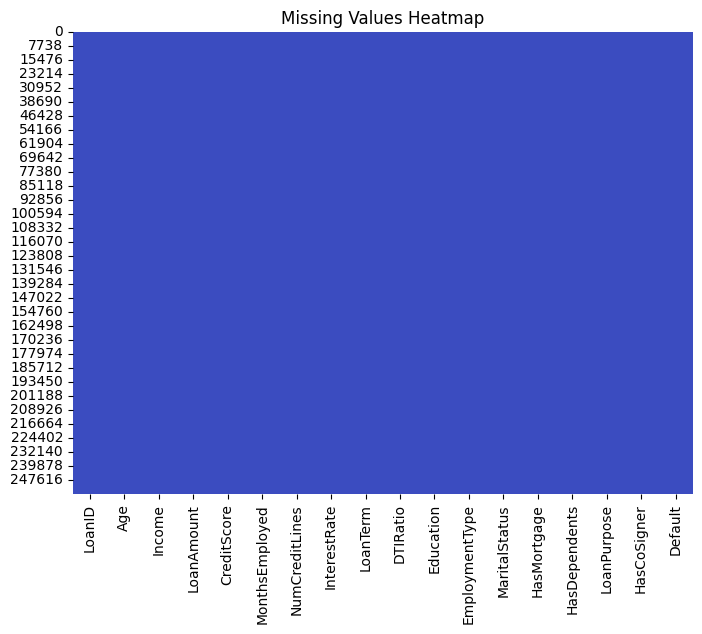

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False, cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.show()

In [9]:
# Fill categorical columns with mode
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numeric columns with median
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())


In [10]:
target = 'Default'
numerical_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
                  'MonthsEmployed', 'NumCreditLines', 'InterestRate',
                  'LoanTerm', 'DTIRatio']

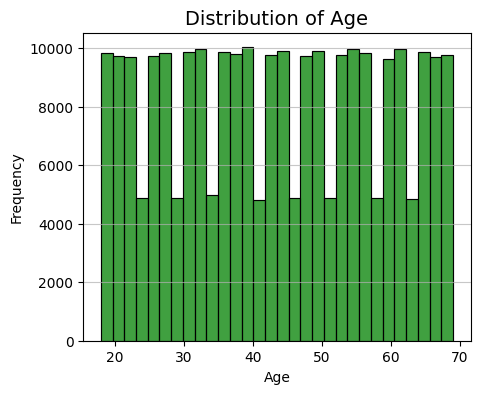

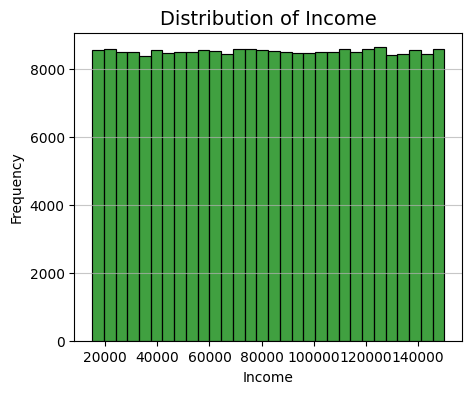

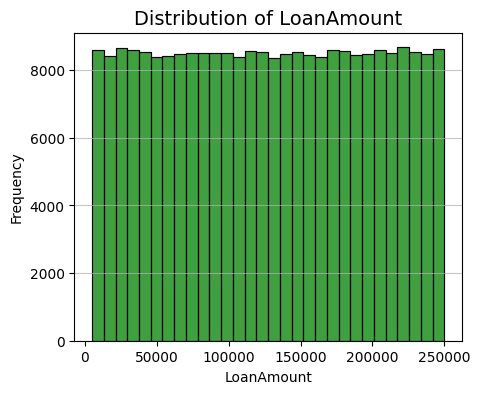

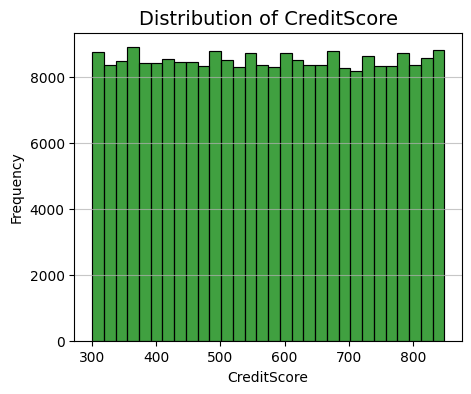

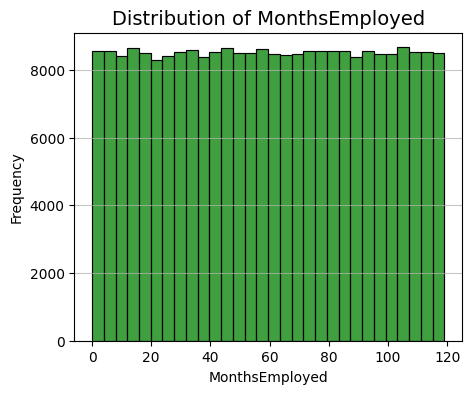

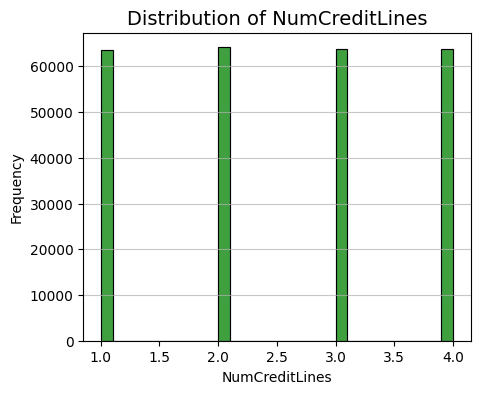

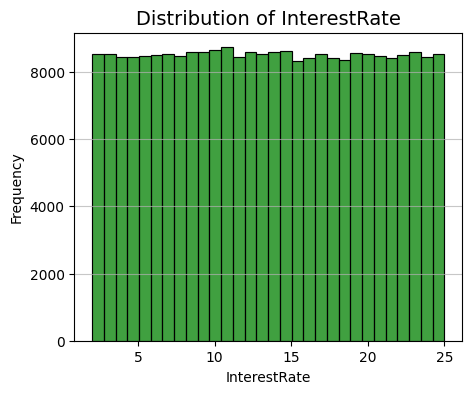

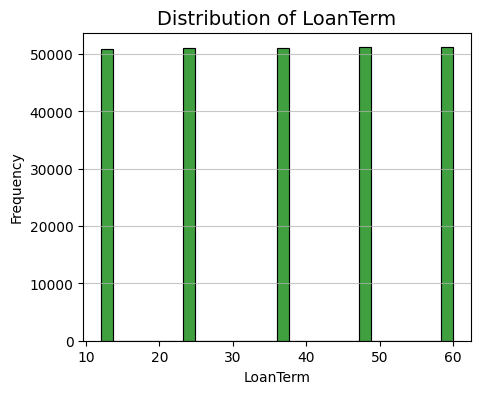

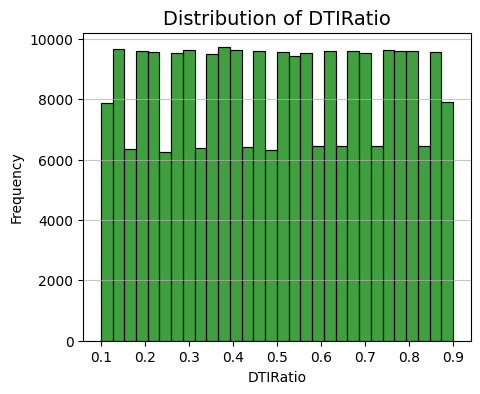

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(5, 4))
    sns.histplot(df[col], bins=30, color='green')
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='-', alpha=0.7)
    plt.show()

In [12]:
categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus',
                    'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

In [13]:
cat_cols = df.select_dtypes(include=["object"]).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

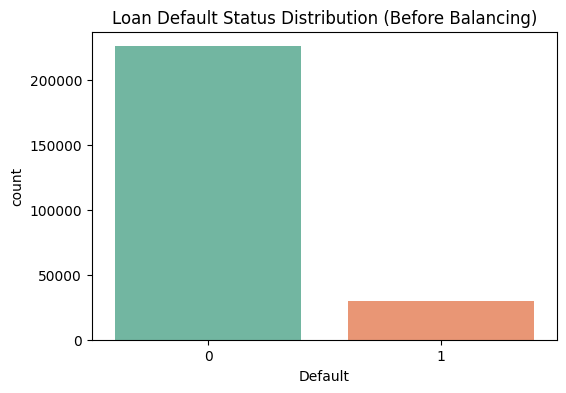

Default
0    225694
1     29653
Name: count, dtype: int64

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Default", data=df, palette="Set2")
plt.title("Loan Default Status Distribution (Before Balancing)")
plt.show()

df["Default"].value_counts()

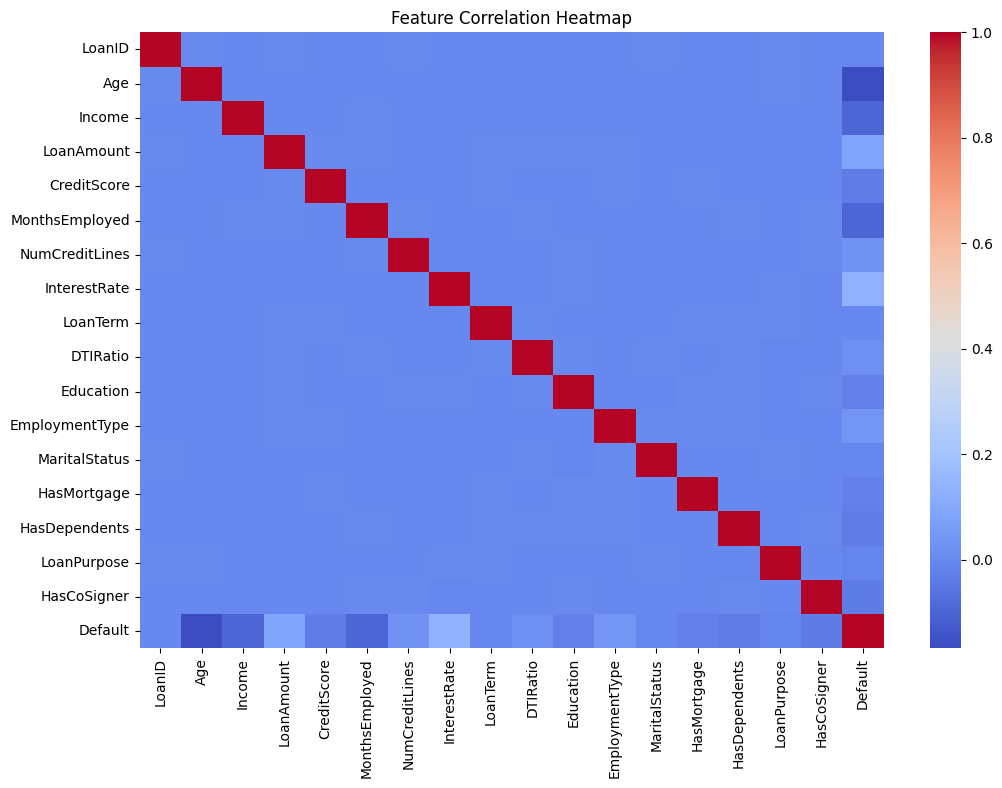

In [15]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


In [16]:
X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [18]:
smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)

print("Before balancing:\n", y_train.value_counts())
print("\nAfter balancing:\n", y_resampled.value_counts())


Before balancing:
 Default
0    180555
1     23722
Name: count, dtype: int64

After balancing:
 Default
1    179711
0    100881
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


--- Evaluation for Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.60      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.51      0.50     51070
weighted avg       0.85      0.89      0.84     51070



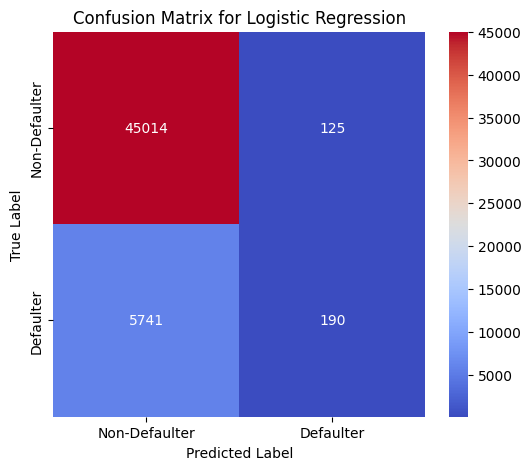

--------------------------------------------------

--- Evaluation for Decision Tree ---
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45139
           1       0.19      0.22      0.21      5931

    accuracy                           0.80     51070
   macro avg       0.54      0.55      0.55     51070
weighted avg       0.81      0.80      0.81     51070



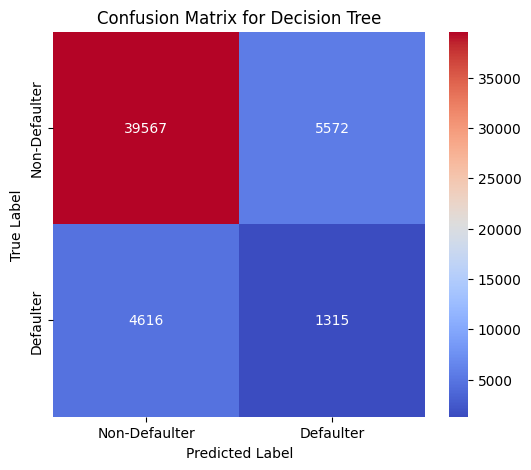

--------------------------------------------------

--- Evaluation for Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.04      0.08      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070



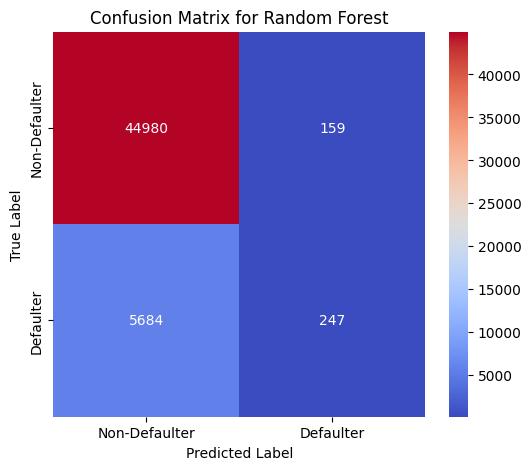

--------------------------------------------------

--- Evaluation for XGBoost ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.54      0.09      0.15      5931

    accuracy                           0.89     51070
   macro avg       0.71      0.54      0.55     51070
weighted avg       0.85      0.89      0.85     51070



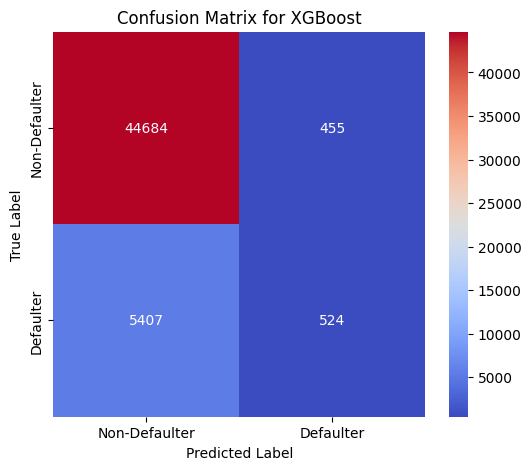

--------------------------------------------------

--- Evaluation for KNN ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     45139
           1       0.30      0.07      0.11      5931

    accuracy                           0.87     51070
   macro avg       0.59      0.52      0.52     51070
weighted avg       0.82      0.87      0.84     51070



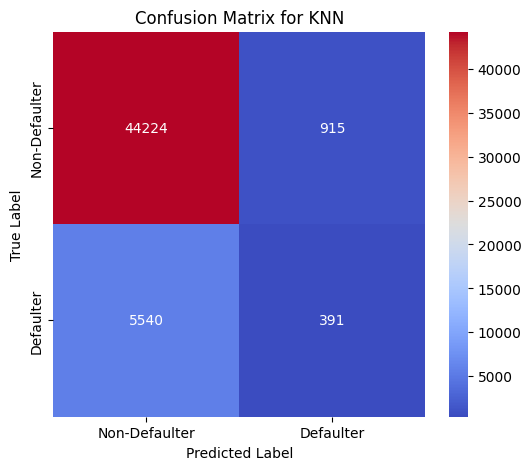

--------------------------------------------------

--- Evaluation for Naive Bayes ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.64      0.02      0.03      5931

    accuracy                           0.88     51070
   macro avg       0.76      0.51      0.48     51070
weighted avg       0.86      0.88      0.83     51070



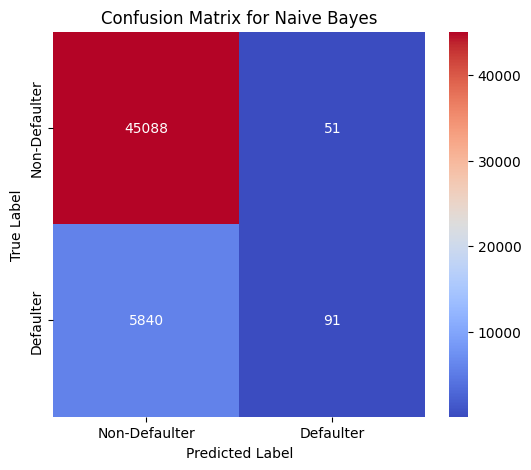

--------------------------------------------------

--- Evaluation for Gradient Boosting ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.62      0.05      0.10      5931

    accuracy                           0.89     51070
   macro avg       0.76      0.52      0.52     51070
weighted avg       0.86      0.89      0.84     51070



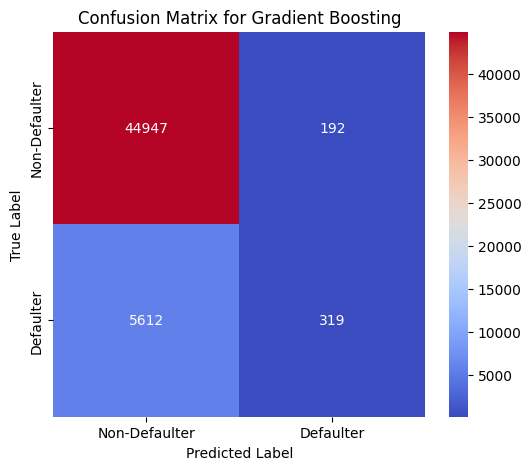

--------------------------------------------------


In [20]:

# --- Define Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    #"SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier()
}

# --- Train/Validation split ---
X_train_full, X_valid, y_train_full, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# --- Dictionary to store results ---
results = {}

# --- Train and Evaluate Each Model ---
for name, model in models.items():
    print(f"\n--- Evaluation for {name} ---")

    # Train on training data
    model.fit(X_train_full, y_train_full)

    # Predictions
    y_train_pred = model.predict(X_train_full)
    y_valid_pred = model.predict(X_valid)
    y_test_pred = model.predict(X_test)

    y_test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    train_acc = accuracy_score(y_train_full, y_train_pred)
    val_acc = accuracy_score(y_valid, y_valid_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    sensitivity = recall_score(y_test, y_test_pred)
    specificity = tn / (tn + fp)
    precision = precision_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    auc = roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else None

    # Save in dictionary
    results[name] = {
        "Train Acc": train_acc,
        "Validation Acc": val_acc,
        "Test Acc": test_acc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1-Score": f1,
        "AUC": auc
    }

    # Print classification report
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred))

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Non-Defaulter', 'Defaulter'],
                yticklabels=['Non-Defaulter', 'Defaulter'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    print("-" * 50)




--- Final Model Comparison ---
                     Train Acc  Validation Acc  Test Acc  Sensitivity  \
Gradient Boosting     0.887010        0.886846  0.886352     0.053785   
Random Forest         0.999957        0.885990  0.885588     0.041646   
XGBoost               0.896476        0.884448  0.885216     0.088349   
Logistic Regression   0.885058        0.885721  0.885138     0.032035   
Naive Bayes           0.884721        0.885256  0.884649     0.015343   
KNN                   0.894444        0.874217  0.873605     0.065925   
Decision Tree         1.000000        0.802110  0.800509     0.221716   

                     Specificity  Precision  F1-Score       AUC  
Gradient Boosting       0.995746   0.624266  0.099038  0.757313  
Random Forest           0.996478   0.608374  0.077955  0.732960  
XGBoost                 0.989920   0.535240  0.151664  0.740011  
Logistic Regression     0.997231   0.603175  0.060839  0.749736  
Naive Bayes             0.998870   0.640845  0.029969

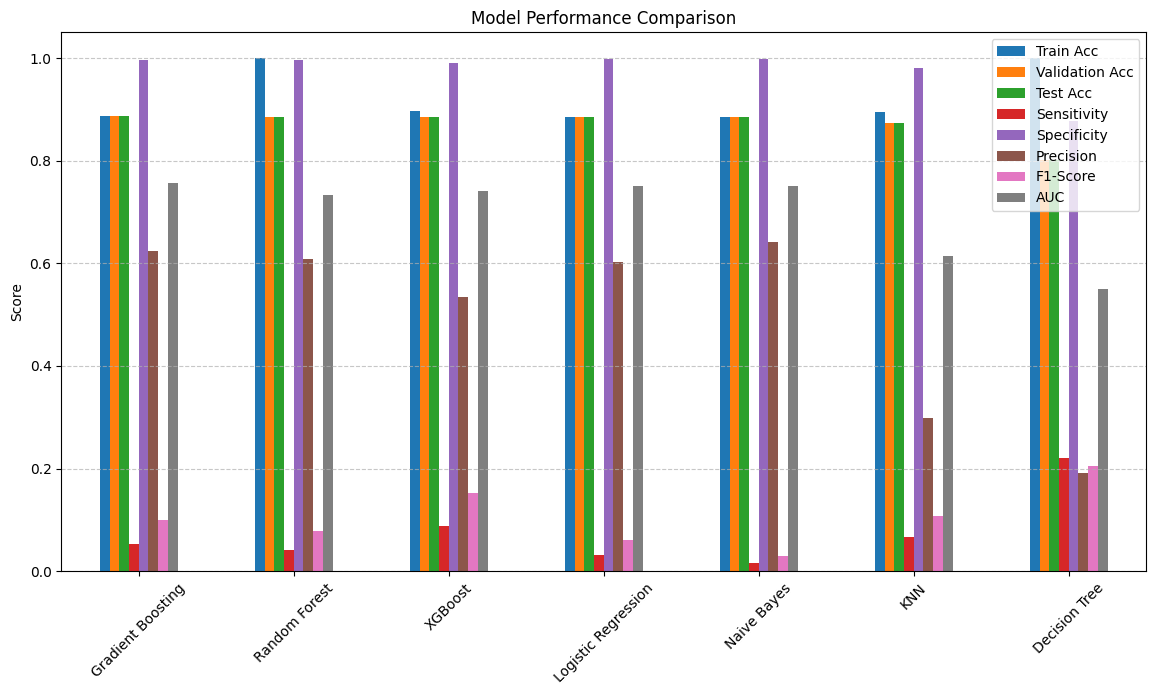

In [21]:
# --- Final Comparison ---
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='Test Acc', ascending=False)

print("\n--- Final Model Comparison ---")
print(results_df)

# --- Export to LaTeX with Multi-column Header ---
latex_table = results_df.rename(columns={
    "Train Acc": "Train",
    "Validation Acc": "Validation",
    "Test Acc": "Test"
}).to_latex(
    index=True, float_format="%.4f", multirow=True, 
    column_format="lccc|cccccc",  # group cols
    header=["Train", "Validation", "Test", "Sensitivity", "Specificity", "Precision", "F1-Score", "AUC"]
)

print("\n--- LaTeX Table ---")
print(latex_table)

# --- Plot the results ---
results_df.plot(kind='bar', figsize=(14, 7))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [22]:
#results_df.to_excel("model_comparison1.xlsx")
